In [1]:
import os, json
import pandas as pd
from numpy import random
import numpy as np
%matplotlib inline

In [2]:
from libcbm.input.sit import sit_cbm_factory
from libcbm.model.cbm import cbm_simulator
from libcbm.model.cbm import cbm_defaults
from libcbm.model.cbm.cbm_output import CBMOutput
from libcbm import resources

In [3]:
rng = random.default_rng()

In [4]:

def run_cbm_random():
    # runs CBM tutorial2 with randomly drawn stem anual turnover rate, to illustrate how to do this
    config_path = os.path.join(resources.get_test_resources_dir(), "cbm3_tutorial2", "sit_config.json")
    sit = sit_cbm_factory.load_sit(config_path)
    classifiers, inventory = sit_cbm_factory.initialize_inventory(sit)

    # get the default CBM parameters: this is a dictionary of name/dataframe pairs
    default_parameters = sit.get_parameters_factory()()

    def random_parameter_factory():
        # update the default parameters table "turnover_parameters"

        turnover_parameters = default_parameters["turnover_parameters"].copy()
        #fetch the StemAnnualTurnoverRate series from the dataframe
        stem_turnover_rate = turnover_parameters["StemAnnualTurnoverRate"]
        # replace the StemAnnualTurnoverRate with values drawn from a distribution
        turnover_parameters["StemAnnualTurnoverRate"] = rng.normal(stem_turnover_rate, stem_turnover_rate / 20.0)
        # convert the dataframe back to the json format used by CBM
        default_parameters["turnover_parameters"] = turnover_parameters
        return default_parameters

    # use the above random parameter factory as the source for CBM parameters
    with sit_cbm_factory.initialize_cbm(sit, parameters_factory=random_parameter_factory) as cbm:

        cbm_output = CBMOutput()
        rule_based_processor = sit_cbm_factory.create_sit_rule_based_processor(sit, cbm)

        cbm_simulator.simulate(
            cbm,
            n_steps              = 20,
            classifiers          = classifiers,
            inventory            = inventory,
            pre_dynamics_func    = rule_based_processor.pre_dynamics_func,
            reporting_func       = cbm_output.append_simulation_result
        )
        # return a single pool value to illustrate the effect of the randomly drawn parameter
        return cbm_output.pools.to_pandas()[["timestep", "SoftwoodStemSnag"]].groupby("timestep").sum()

In [5]:
# run 20 iterations of the random parameter override
results = {f"sw_stem_snag_iteration_{i}": run_cbm_random()["SoftwoodStemSnag"] for i in range(1,20+1)}

<Axes: xlabel='timestep'>

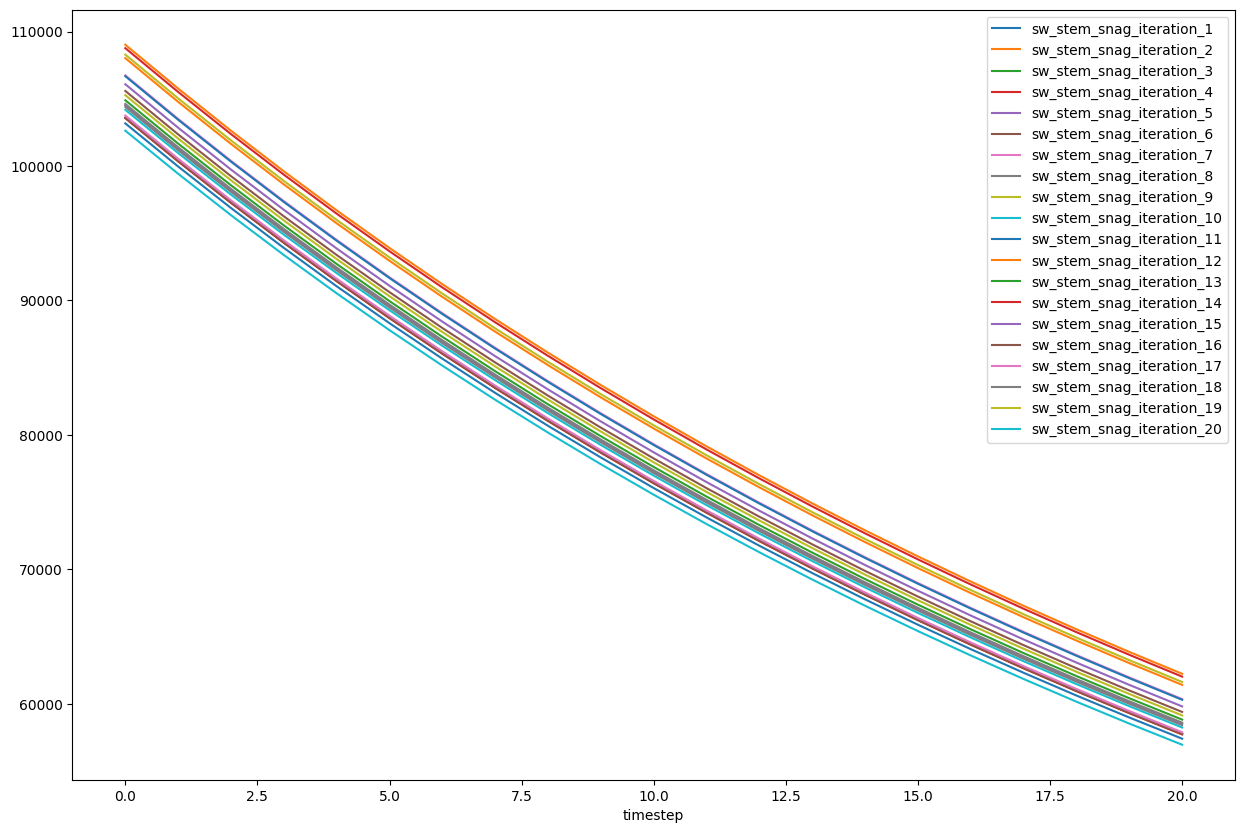

In [6]:
pd.DataFrame(results).plot(figsize=(15,10))